In [228]:
#Task 1.1 Variable Roles and Data Types
import pandas as pd
import numpy as np

df = pd.read_csv('dataset_ifn580_262_v1.csv')

columns_to_check = [
    'destination',
    'passanger',
    'weather',
    'coupon',
    'expiration',
    'gender',
    'maritalStatus',
    'education',
    'occupation'
]

for col in columns_to_check:
    print(col, ":", df[col].unique())

destination : ['No Urgent Place' 'Home' 'Work']
passanger : ['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
weather : ['Sunny' 'Rainy' 'Snowy']
coupon : ['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']
expiration : ['1d' '2h']
gender : ['Female' 'Male']
maritalStatus : ['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
education : ['Some college - no degree' 'Bachelors degree' 'Associates degree'
 'High School Graduate' 'Graduate degree (Masters or Doctorate)'
 'Some High School']
occupation : ['Unemployed' 'Architecture & Engineering' 'Student'
 'Education&Training&Library' 'Healthcare Support'
 'Healthcare Practitioners & Technical' 'Sales & Related' 'Management'
 'Arts Design Entertainment Sports & Media' 'Computer & Mathematical'
 'Life Physical Social Science' 'Personal Care & Service'
 'Community & Social Services' 'Office & Administrative Support'
 'Construction & Extraction' 'Legal' 'Retired'
 'Installation Maintenance & Repair' 

In [229]:
# Task 1.2 Data Quality, Cleaning and Preprocessing
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percent
})

missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

display(missing_summary)

,Missing Count,Missing Percentage
temperature,250,1.970987
car,12576,99.148534
Bar,107,0.843582
CoffeeHouse,217,1.710817
CarryAway,151,1.190476
RestaurantLessThan20,130,1.024913
Restaurant20To50,189,1.490066


In [230]:
print("Mean:", df['temperature'].mean())
print("Median:", df['temperature'].median())

Mean: 63.28976998552356
Median: 80.0


In [231]:
for col in ['Bar']:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

Bar
Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64



In [232]:
for col in ['CoffeeHouse']:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

CoffeeHouse
CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
NaN       217
Name: count, dtype: int64



In [233]:
for col in ['CarryAway']:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

CarryAway
CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
NaN       151
Name: count, dtype: int64



In [234]:
for col in ['RestaurantLessThan20']:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

RestaurantLessThan20
RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
NaN       130
Name: count, dtype: int64



In [235]:
for col in ['Restaurant20To50']:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

Restaurant20To50
Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
NaN       189
Name: count, dtype: int64



In [236]:
# Task 1.3 Mixed Numerical/Textual Representation and Time

df = df.drop(columns=['car'])
df['temperature'] = df['temperature'].fillna(df['temperature'].median())
df['Bar'] = df['Bar'].fillna(df['Bar'].mode()[0])
df['CoffeeHouse'] = df['CoffeeHouse'].fillna(df['CoffeeHouse'].mode()[0])
df['CarryAway'] = df['CarryAway'].fillna(df['CarryAway'].mode()[0])
df['RestaurantLessThan20'] = df['RestaurantLessThan20'].fillna(df['RestaurantLessThan20'].mode()[0])
df['Restaurant20To50'] = df['Restaurant20To50'].fillna(df['Restaurant20To50'].mode()[0])

df.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
is_accepted             0
dtype: int64

In [237]:
# encoding(maping)
age_mapping = {
    'below21': 0,
    '21':1,
    '26':2,
    '31':3,
    '36':4,
    '41':5,
    '46':6,
    '50plus': 7
}
df['age'] = df['age'].map(age_mapping)

In [238]:
df['age'].unique()

array([1, 6, 2, 3, 5, 7, 4, 0], dtype=int64)

In [239]:
df['age'].isnull().sum()

0

In [240]:
time_mapping = {
    '7AM': 0,
    '10AM': 1,
    '2PM': 2,
    '6PM': 3,
    '10PM': 4
}
df['time'] = df['time'].map(time_mapping)

In [241]:
df['time'].unique()

array([2, 1, 3, 0, 4], dtype=int64)

In [242]:
df['time'].isnull().sum()

0

In [243]:
income_mapping = {
    'Less than $12500': 0,
    '$12500 - $24999': 1,
    '$25000 - $37499': 2,
    '$37500 - $49999': 3,
    '$50000 - $62499': 4,
    '$62500 - $74999': 5,
    '$75000 - $87499': 6,
    '$87500 - $99999': 7,
    '$100000 or More': 8
}
df['income'] = df['income'].map(income_mapping)

In [244]:
df['income'].unique()

array([3, 5, 1, 6, 4, 2, 8, 7, 0], dtype=int64)

In [245]:
df['income'].isnull().sum()

0

In [246]:
df['education'].unique()

array(['Some college - no degree', 'Bachelors degree',
       'Associates degree', 'High School Graduate',
       'Graduate degree (Masters or Doctorate)', 'Some High School'],
      dtype=object)

In [247]:
education_mapping = {
    'Some High School': 0,
    'High School Graduate': 1,
    'Some college - no degree': 2,
    'Associates degree': 3,
    'Bachelors degree': 4,
    'Graduate degree (Masters or Doctorate)': 5
}
df['education'] = df['education'].map(education_mapping)

In [248]:
df['education'].unique()

array([2, 4, 3, 1, 5, 0], dtype=int64)

In [249]:
df['education'].isnull().sum()

0

In [250]:
frequency_mapping = {
    'never': 0,
    'less1': 1,
    '1~3': 2,
    '4~8': 3,
    'gt8': 4
}
frequency_columns = [
    'Bar',
    'CoffeeHouse',
    'CarryAway',
    'RestaurantLessThan20',
    'Restaurant20To50'
]

for col in frequency_columns:
    df[col] = df[col].map(frequency_mapping)

In [251]:
df[frequency_columns].isnull().sum()

Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
dtype: int64

In [252]:
for col in frequency_columns:
    print(col, df[col].unique())

Bar [0 1 2 4 3]
CoffeeHouse [0 1 3 2 4]
CarryAway [2 3 4 1 0]
RestaurantLessThan20 [3 2 1 4 0]
Restaurant20To50 [2 1 0 4 3]


In [253]:
expiration_mapping = {
    '2h': 0,
    '1d': 1
}
df['expiration'] = df['expiration'].map(expiration_mapping)

In [254]:
df['expiration'].unique()

array([1, 0], dtype=int64)

In [255]:
df['expiration'].isnull().sum()

0

In [256]:
gender_mapping = {
    'Female': 0,
    'Male': 1
}
df['gender'] = df['gender'].map(gender_mapping)

In [257]:
df['gender'].unique()

array([0, 1], dtype=int64)

In [258]:
destination_encoded = pd.get_dummies(
    df['destination'],
    prefix='destination',
    dtype=int
)

In [259]:
destination_encoded.head()

,destination_Home,destination_No Urgent Place,destination_Work
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


In [260]:
df = pd.concat([df, destination_encoded], axis=1)

In [261]:
df = df.drop(columns=['destination'])

In [262]:
df.head()

,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,...,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,is_accepted,destination_Home,destination_No Urgent Place,destination_Work
0,Alone,Sunny,55.0,2,Restaurant(<20),1,0,1,Unmarried partner,1,...,2,1,0,0,0,1,1,0,1,0
1,Friend(s),Sunny,80.0,1,Coffee House,0,0,1,Unmarried partner,1,...,2,1,0,0,0,1,0,0,1,0
2,Friend(s),Sunny,80.0,1,Carry out & Take away,0,0,1,Unmarried partner,1,...,2,1,1,0,0,1,1,0,1,0
3,Friend(s),Sunny,80.0,2,Coffee House,0,0,1,Unmarried partner,1,...,2,1,1,0,0,1,0,0,1,0
4,Friend(s),Sunny,80.0,2,Coffee House,1,0,1,Unmarried partner,1,...,2,1,1,0,0,1,0,0,1,0


In [263]:
nominal_columns = [
    'passanger',
    'weather',
    'coupon',
    'maritalStatus',
    'occupation'
]
nominal_encoded = pd.get_dummies(
    df[nominal_columns],
    prefix=nominal_columns,
    dtype=int
)
df = pd.concat([df, nominal_encoded], axis=1)

In [264]:
df = df.drop(columns=nominal_columns)

In [265]:
df.head()

,temperature,time,expiration,gender,age,has_children,education,income,Bar,CoffeeHouse,...,occupation_Management,occupation_Office & Administrative Support,occupation_Personal Care & Service,occupation_Production Occupations,occupation_Protective Service,occupation_Retired,occupation_Sales & Related,occupation_Student,occupation_Transportation & Material Moving,occupation_Unemployed
0,55.0,2,1,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
1,80.0,1,0,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
2,80.0,1,0,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
3,80.0,2,0,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
4,80.0,2,1,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1


In [266]:
df.dtypes

temperature                                    float64
time                                             int64
expiration                                       int64
gender                                           int64
age                                              int64
                                                ...   
occupation_Retired                               int32
occupation_Sales & Related                       int32
occupation_Student                               int32
occupation_Transportation & Material Moving      int32
occupation_Unemployed                            int32
Length: 64, dtype: object

In [267]:
# Task 1.4 – Correlation Analysis and Redundant Variables

df.select_dtypes(exclude='number').columns

Index([], dtype='object')

In [268]:
df.dtypes[df.dtypes == 'object']

Series([], dtype: object)

In [269]:
correlation_matrix = df.corr()

In [270]:
correlation_matrix

,temperature,time,expiration,gender,age,has_children,education,income,Bar,CoffeeHouse,...,occupation_Management,occupation_Office & Administrative Support,occupation_Personal Care & Service,occupation_Production Occupations,occupation_Protective Service,occupation_Retired,occupation_Sales & Related,occupation_Student,occupation_Transportation & Material Moving,occupation_Unemployed
temperature,1.000000,-0.035530,-0.121833,-0.025419,-0.017893,-0.019894,0.008683,-0.029969,-0.005448,-0.016049,...,0.040296,-0.019941,-0.003830,-0.001028,0.022685,0.021477,-0.003243,0.022421,0.002254,-0.029577
time,-0.035530,1.000000,-0.030381,-0.003593,0.005114,0.026883,0.009751,0.010860,-0.014447,-0.000058,...,-0.020176,0.001148,0.003669,0.007005,-0.010955,-0.013038,0.000643,-0.008162,0.000166,0.019036
expiration,-0.121833,-0.030381,1.000000,0.001264,-0.021208,-0.016020,-0.016356,-0.020606,-0.009821,-0.002195,...,-0.014373,0.025240,-0.003858,0.017989,-0.007942,-0.007158,-0.002287,0.016554,0.000155,0.008767
gender,-0.025419,-0.003593,0.001264,1.000000,-0.099847,-0.159956,-0.004301,0.101738,0.161595,-0.044470,...,0.088371,-0.097346,-0.027272,0.058632,0.033578,0.013924,0.057932,0.092138,0.055712,-0.137959
age,-0.017893,0.005114,-0.021208,-0.099847,1.000000,0.442096,0.158249,0.084885,-0.158573,-0.049766,...,0.060981,0.025226,0.110139,0.067808,0.021135,0.313798,-0.000859,-0.396503,0.075858,-0.082651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
occupation_Retired,0.021477,-0.013038,-0.007158,0.013924,0.313798,0.114056,0.051814,-0.002094,-0.132851,-0.085394,...,-0.053599,-0.046416,-0.023836,-0.018849,-0.023836,1.000000,-0.061883,-0.076126,-0.026649,-0.083800
occupation_Sales & Related,-0.003243,0.000643,-0.002287,0.057932,-0.000859,-0.046576,-0.032885,-0.063590,-0.009931,-0.050215,...,-0.081674,-0.070729,-0.036321,-0.028722,-0.036321,-0.061883,1.000000,-0.116002,-0.040608,-0.127696
occupation_Student,0.022421,-0.008162,0.016554,0.092138,-0.396503,-0.222232,-0.145635,-0.117955,-0.021115,0.125814,...,-0.100474,-0.087009,-0.044681,-0.035333,-0.044681,-0.076126,-0.116002,1.000000,-0.049955,-0.157088
occupation_Transportation & Material Moving,0.002254,0.000166,0.000155,0.055712,0.075858,0.048911,-0.066045,-0.002199,0.009791,-0.007444,...,-0.035172,-0.030459,-0.015641,-0.012369,-0.015641,-0.026649,-0.040608,-0.049955,1.000000,-0.054991


In [271]:
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) > 0.90:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_value
            ))

high_corr_pairs

[('direction_opp', 'direction_same', -1.0)]

In [272]:
df = df.drop(columns=['direction_opp'])

In [273]:
correlation_matrix = df.corr()

In [274]:
'direction_opp' in df.columns

False

# Task 2 – Decision Tree

In [275]:
# Task 2.1 – Default Decision Tree
X = df.drop(columns=['is_accepted'])
y = df['is_accepted']

# Train-Test Split
The processed dataset was divided into 70% training data and 30% testing data.

In [276]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [277]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8878, 62)
(3806, 62)
(8878,)
(3806,)


In [278]:
from sklearn.tree import DecisionTreeClassifier

# Default Decision Tree Model
A default Decision Tree classifier was trained using the training dataset.

In [279]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [280]:
train_accuracy = dt_default.score(X_train, y_train)
test_accuracy = dt_default.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.9985357062401442
Test Accuracy: 0.6694692590646348


# Accuracy
- Training: 0.9985
- Testing: 0.6695
- large gap between training and testing
- possible overfitting

In [281]:
print("Number of Rules:", dt_default.get_n_leaves())

Number of Rules: 2290


In [282]:
from sklearn.tree import export_text

tree_rules = export_text(
    dt_default,
    feature_names=list(X.columns),
    max_depth=2
)

print(tree_rules)

|--- coupon_Carry out & Take away <= 0.50
|   |--- coupon_Restaurant(<20) <= 0.50
|   |   |--- CoffeeHouse <= 1.50
|   |   |   |--- truncated branch of depth 22
|   |   |--- CoffeeHouse >  1.50
|   |   |   |--- truncated branch of depth 23
|   |--- coupon_Restaurant(<20) >  0.50
|   |   |--- toCoupon_GEQ25min <= 0.50
|   |   |   |--- truncated branch of depth 21
|   |   |--- toCoupon_GEQ25min >  0.50
|   |   |   |--- truncated branch of depth 15
|--- coupon_Carry out & Take away >  0.50
|   |--- expiration <= 0.50
|   |   |--- temperature <= 42.50
|   |   |   |--- truncated branch of depth 16
|   |   |--- temperature >  42.50
|   |   |   |--- truncated branch of depth 27
|   |--- expiration >  0.50
|   |   |--- education <= 4.50
|   |   |   |--- truncated branch of depth 18
|   |   |--- education >  4.50
|   |   |   |--- truncated branch of depth 15



In [283]:
print("Tree Depth:", dt_default.get_depth())
print("Number of Nodes:", dt_default.tree_.node_count)

Tree Depth: 29
Number of Nodes: 4579


# First and Second Splits

- First split: `coupon_Carry out & Take away`
- Second splits: `coupon_Restaurant(<20)` and `expiration`

# Tree Size
- Depth: 29
- Nodes: 4579
- Rules: 2290
- Large and deep tree
- likely overfitting

# Top 12 Important Variables


In [284]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_default.feature_importances_
})

top_12_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(12)

top_12_features

,Feature,Importance
7,income,0.071359
9,CoffeeHouse,0.064662
4,age,0.060753
8,Bar,0.049374
1,time,0.044157
10,CarryAway,0.043754
12,Restaurant20To50,0.043021
6,education,0.042308
31,coupon_Restaurant(<20),0.037414
11,RestaurantLessThan20,0.035487


# Default Model Parameters


In [285]:
dt_default.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 42,
 'splitter': 'best'}

# Default Parameters
- criterion: gini
- splitter: best
- max_depth: None
- min_samples_split: 2
- min_samples_leaf: 1

In [286]:
# Task 2.2 – Tuned Decision Tree with GridSearchCV
from sklearn.model_selection import GridSearchCV

# Parameter Grid
- For max_depth, I test values smaller than the default depth of 29 to restrict tree growth.
- Higher min_samples_split can stop the tree from creating splits that only involve very few samples.
- I increase min_samples_leaf values to prevent tiny leaf nodes, which is a common source of over‑fitting.
- Two split criteria, Gini and Entropy, are compared within this parameter search.

In [287]:
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt_grid = DecisionTreeClassifier(random_state=42)

In [288]:
grid_search = GridSearchCV(
    estimator=dt_grid,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

In [289]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [290]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 20}
Best CV Score: 0.6911478238802182


In [291]:
dt_tuned = grid_search.best_estimator_

In [292]:
tuned_train_accuracy = dt_tuned.score(X_train, y_train)
tuned_test_accuracy = dt_tuned.score(X_test, y_test)

print("Tuned Training Accuracy:", tuned_train_accuracy)
print("Tuned Testing Accuracy:", tuned_test_accuracy)

Tuned Training Accuracy: 0.770218517684163
Tuned Testing Accuracy: 0.6981082501313716


# Best Parameters:
criterion = entropy

max_depth = 10

min_samples_leaf = 1

min_samples_split = 20

Best CV Score = 0.6911

Tuned Training Accuracy = 0.7702

Tuned Testing Accuracy = 0.6981

In [293]:
print("Tuned Tree Depth:", dt_tuned.get_depth())
print("Tuned Number of Nodes:", dt_tuned.tree_.node_count)
print("Tuned Number of Rules:", dt_tuned.get_n_leaves())

Tuned Tree Depth: 10
Tuned Number of Nodes: 647
Tuned Number of Rules: 324


In [294]:
from sklearn.tree import export_text

tuned_tree_rules = export_text(
    dt_tuned,
    feature_names=list(X.columns),
    max_depth=2
)

print(tuned_tree_rules)

|--- coupon_Carry out & Take away <= 0.50
|   |--- coupon_Restaurant(<20) <= 0.50
|   |   |--- CoffeeHouse <= 1.50
|   |   |   |--- truncated branch of depth 8
|   |   |--- CoffeeHouse >  1.50
|   |   |   |--- truncated branch of depth 8
|   |--- coupon_Restaurant(<20) >  0.50
|   |   |--- toCoupon_GEQ25min <= 0.50
|   |   |   |--- truncated branch of depth 8
|   |   |--- toCoupon_GEQ25min >  0.50
|   |   |   |--- truncated branch of depth 8
|--- coupon_Carry out & Take away >  0.50
|   |--- expiration <= 0.50
|   |   |--- temperature <= 42.50
|   |   |   |--- truncated branch of depth 8
|   |   |--- temperature >  42.50
|   |   |   |--- truncated branch of depth 8
|   |--- expiration >  0.50
|   |   |--- education <= 3.50
|   |   |   |--- truncated branch of depth 8
|   |   |--- education >  3.50
|   |   |   |--- truncated branch of depth 8



# First and Second Splits

- First split: `coupon_Carry out & Take away`
- Second splits: `coupon_Restaurant(<20)` and `expiration`

# Tuned Top 12 Important Variables

In [295]:
feature_importance_tuned = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_tuned.feature_importances_
})

top_12_features_tuned = feature_importance_tuned.sort_values(
    by='Importance',
    ascending=False
).head(12)

top_12_features_tuned

,Feature,Importance
9,CoffeeHouse,0.100909
31,coupon_Restaurant(<20),0.082108
28,coupon_Carry out & Take away,0.058340
2,expiration,0.057152
4,age,0.050888
7,income,0.050837
15,toCoupon_GEQ25min,0.047924
29,coupon_Coffee House,0.044665
8,Bar,0.044224
1,time,0.038083


# Comparison of Important Variables

In [296]:
import pandas as pd

df_default = top_12_features.copy()
df_tuned = top_12_features_tuned.copy()

df_default = df_default.rename(columns={"Importance":"Importance_Default"})
df_tuned = df_tuned.rename(columns={"Importance":"Importance_Tuned"})

df_compare = pd.merge(
    df_default,
    df_tuned,
    on="Feature",
    how="outer"
).sort_values("Importance_Tuned", ascending=False)

df_compare["In_Default_Top12"] = df_compare["Importance_Default"].notna()
df_compare["In_Tuned_Top12"] = df_compare["Importance_Tuned"].notna()
df_compare["Importance_Change"] = (df_compare["Importance_Tuned"] - df_compare["Importance_Default"])

display(df_compare)

,Feature,Importance_Default,Importance_Tuned,In_Default_Top12,In_Tuned_Top12,Importance_Change
1,CoffeeHouse,0.064662,0.100909,True,True,0.036248
8,coupon_Restaurant(<20),0.037414,0.082108,True,True,0.044694
12,coupon_Carry out & Take away,NaN,0.058340,False,True,NaN
13,expiration,NaN,0.057152,False,True,NaN
2,age,0.060753,0.050888,True,True,-0.009865
0,income,0.071359,0.050837,True,True,-0.020521
10,toCoupon_GEQ25min,0.030926,0.047924,True,True,0.016998
14,coupon_Coffee House,NaN,0.044665,False,True,NaN
3,Bar,0.049374,0.044224,True,True,-0.005150
4,time,0.044157,0.038083,True,True,-0.006074


In [297]:
# Task 2.3 ROC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [298]:
default_prob = dt_default.predict_proba(X_test)[:, 1]
tuned_prob = dt_tuned.predict_proba(X_test)[:, 1]

In [299]:
fpr_default, tpr_default, _ = roc_curve(y_test, default_prob)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_prob)

auc_default = roc_auc_score(y_test, default_prob)
auc_tuned = roc_auc_score(y_test, tuned_prob)

print("Default AUC:", auc_default)
print("Tuned AUC:", auc_tuned)

Default AUC: 0.6635839200110883
Tuned AUC: 0.7437721629523295


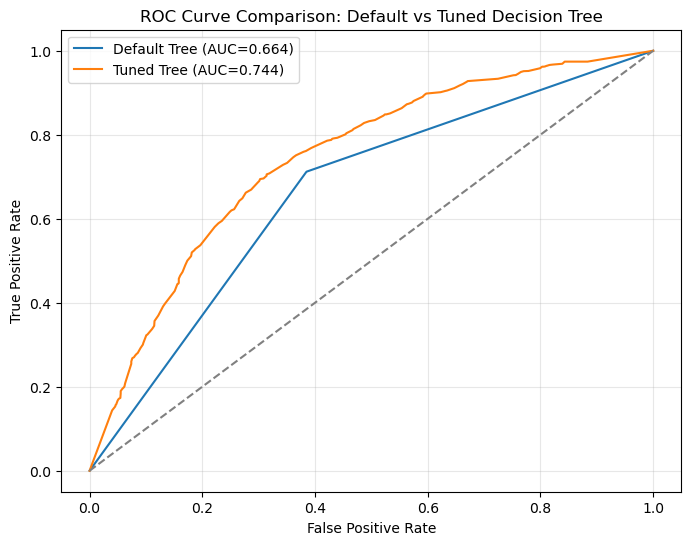

In [300]:
plt.figure(figsize=(8,6))

plt.plot(fpr_default, tpr_default,
         label=f"Default Tree (AUC={auc_default:.3f})")

plt.plot(fpr_tuned, tpr_tuned,
         label=f"Tuned Tree (AUC={auc_tuned:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Default vs Tuned Decision Tree")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ROC Observation
- Default AUC: 0.6636
- Tuned AUC: 0.7438
- Tuned tree performs better on ROC/AUC.

In [301]:
# Task 2.4 – Default vs Tuned Decision Tree Comparison

import time
from sklearn.tree import DecisionTreeClassifier

start = time.time()

dt_default_time = DecisionTreeClassifier(random_state=42)
dt_default_time.fit(X_train, y_train)

end = time.time()

default_train_time = end - start
print(f"Default tree training time: {default_train_time:.4f} s")

Default tree training time: 0.0379 s


In [302]:
start = time.time()

grid_search.fit(X_train, y_train)

end = time.time()

grid_train_time = end - start
print(f"GridSearchCV training time: {grid_train_time:.4f} s")

GridSearchCV training time: 14.6081 s


In [303]:
import time

start = time.time()
dt_tuned.fit(X_train, y_train)
end = time.time()
tuned_train_time = end - start
print(f"Tuned single tree training time: {tuned_train_time:.4f} s")

Tuned single tree training time: 0.0279 s


# Performance:
Tuned test accuracy higher
Tuned AUC higher

Overfitting:
Default train-test gap very large
Tuned gap much smaller

Complexity:
Depth 29 → 10
Nodes 4579 → 647
Rules 2290 → 324

Computational cost:
GridSearchCV much slower than training one default tree

Feature importance:
Several important variables remain common,
but tuning changes some rankings/features

# comparison table

In [304]:
comparison_table = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "AUC",
        "Train-Test Gap",
        "Tree Depth",
        "Number of Nodes",
        "Number of Rules",
        "Computational Time (s)"
    ],
    "Default Tree": [
        0.9985,
        0.6695,
        0.6636,
        0.9985 - 0.6695,
        29,
        4579,
        2290,
        0.0381
    ],
    "Tuned Tree": [
        0.7702,
        0.6981,
        0.7438,
        0.7702 - 0.6981,
        10,
        647,
        324,
        14.5582
    ]
})

display(comparison_table)

,Metric,Default Tree,Tuned Tree
0,Training Accuracy,0.9985,0.7702
1,Testing Accuracy,0.6695,0.6981
2,AUC,0.6636,0.7438
3,Train-Test Gap,0.3290,0.0721
4,Tree Depth,29.0000,10.0000
5,Number of Nodes,4579.0000,647.0000
6,Number of Rules,2290.0000,324.0000
7,Computational Time (s),0.0381,14.5582


# Note
- Tuned computational time refers to the full GridSearchCV process rather than the final tuned tree fit time.

# Comparison Conclusion

- Compared with the default decision‑tree, the tuned model delivers improved test‑set accuracy and higher AUC‑ROC score.
- The gap between training‑ and test‑set performance shrinks significantly after hyper‑parameter tuning, which demonstrates successful mitigation of over‑fitting.
- Model complexity drops visibly: the optimised tree has reduced depth, fewer nodes and a smaller number of decision rules.
- Although GridSearchCV brings substantial extra computational overhead for cross‑validated parameter searching, the final tuned model achieves stronger generalisation with lower complexity.

# Task 3/4

For Task 3 / Task 4 reduced models, the best Decision Tree is the GridSearchCV tuned model.

Best parameters: criterion='entropy', max_depth=10, min_samples_leaf=1, min_samples_split=20.

Tuned performance: train accuracy 0.7702, test accuracy 0.6981, AUC 0.7438.

Top 12 features from the tuned Decision Tree:
CoffeeHouse, coupon_Restaurant(<20), coupon_Carry out & Take away, expiration, age, income, toCoupon_GEQ25min, coupon_Coffee House, Bar, time, RestaurantLessThan20, Restaurant20To50.

Use the final preprocessed Task 1 dataset. It has 62 input features before reduction, target is is_accepted, and Task 2 used a 70:30 train/test split with random_state=42.